# E-commerce Return Prediction — EDA

## Objective
Understand the drivers and patterns behind product returns before building a predictive model.

**Prediction point:** immediately after an order is placed. Only order-time information is used.

### Business questions
1. What is the overall return rate?
2. Which product categories have the highest return rates?
3. Does customer return history relate to future returns?
4. Does discounting relate to returns?
5. Do payment methods show different return behavior?
6. Does product rating relate to returns?
7. Does delivery distance / expected delivery time matter?
8. Are there data-quality or class-imbalance concerns before modeling?


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

from pathlib import Path
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path('../').resolve()
DATA_PATH = str(PROJECT_ROOT / 'data' / 'processed' / 'orders_clean.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['order_date'])

print(f'Shape: {df.shape}')
df.head()

Shape: (40000, 22)


,order_id,order_date,customer_id,product_id,category,product_price,product_rating,product_historical_return_rate,customer_age,customer_previous_orders,customer_previous_returns,customer_return_rate,quantity,discount_pct,payment_type,delivery_distance_km,expected_delivery_days,discount_bucket,price_bucket,order_month,order_day_of_week,returned
0,O000001,2025-01-01 00:00:00.000000,C06310,P02367,Books,464.750,3.410,0.043,26,3,1,0.333,1,9.300,UPI,13.200,3,Low,Budget,1,2,1
1,O000002,2025-01-01 00:13:06.259656,C03958,P02113,Fashion,533.300,3.640,0.162,52,9,0,0.000,1,24.800,UPI,13.200,3,Medium,Mid,1,2,0
2,O000003,2025-01-01 00:26:12.519312,C07049,P02351,Home & Kitchen,"2,346.870",3.520,0.072,55,4,2,0.500,1,13.600,COD,15.500,3,Medium,Premium,1,2,0
3,O000004,2025-01-01 00:39:18.778969,C05519,P01205,Sports,"5,070.840",3.680,0.163,44,5,1,0.200,1,6.600,UPI,22.500,4,Low,Luxury,1,2,0
4,O000005,2025-01-01 00:52:25.038625,C01877,P02232,Fashion,"2,759.510",4.240,0.296,28,5,0,0.000,1,36.700,UPI,2.600,2,High,Premium,1,2,1


## 1. Data quality and structure

In [2]:
print('Data types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
display(df.isna().sum().to_frame('missing').query('missing > 0'))

print('\nDuplicate order IDs:', df['order_id'].duplicated().sum())
print('Unique customers:', df['customer_id'].nunique())
print('Unique products:', df['product_id'].nunique())
print('Date range:', df['order_date'].min().date(), 'to', df['order_date'].max().date())

Data types:


,dtype
order_id,str
order_date,datetime64[us]
customer_id,str
product_id,str
category,str
product_price,float64
product_rating,float64
product_historical_return_rate,float64
customer_age,int64
customer_previous_orders,int64



Missing values:


,missing



Duplicate order IDs: 0
Unique customers: 7944
Unique products: 2500
Date range: 2025-01-01 to 2025-12-31


## 2. Target distribution

A return prediction model is a binary classification problem. We first need to understand the base rate.

,orders,share
returned,,
Not Returned,31416,0.785
Returned,8584,0.215


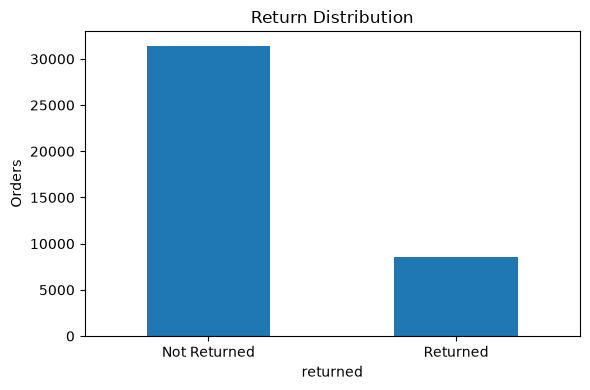

In [3]:
target_summary = (
    df['returned']
    .value_counts()
    .rename(index={0: 'Not Returned', 1: 'Returned'})
    .to_frame('orders')
)
target_summary['share'] = target_summary['orders'] / len(df)
display(target_summary)

plt.figure(figsize=(6, 4))
df['returned'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0, 1], ['Not Returned', 'Returned'], rotation=0)
plt.ylabel('Orders')
plt.title('Return Distribution')
plt.tight_layout()
plt.show()

## 3. Return rate by product category

,orders,return_rate
category,,
Fashion,9536,32.6%
Footwear,4765,32.4%
Home & Kitchen,6061,16.5%
Sports,4180,15.9%
Electronics,5690,15.9%
Beauty,4971,14.2%
Books,4797,13.8%


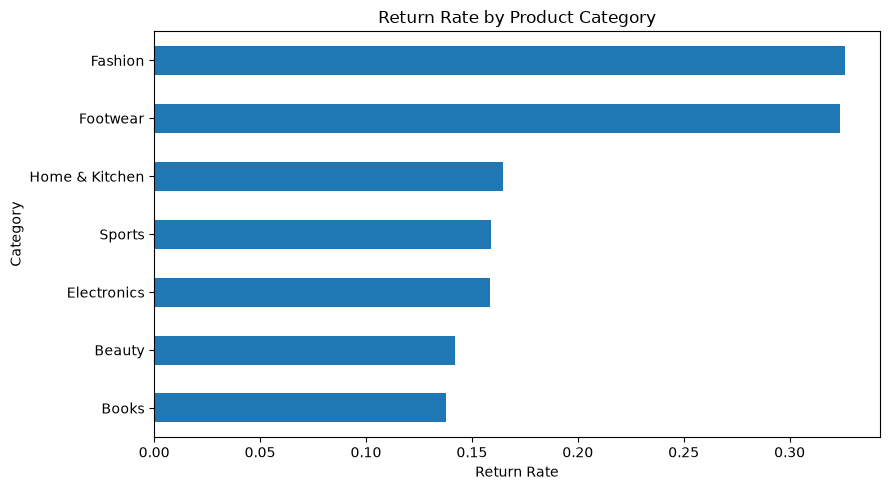

In [4]:
category_returns = (
    df.groupby('category')
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
      .sort_values('return_rate', ascending=False)
)
display(category_returns.style.format({'return_rate': '{:.1%}'}))

plt.figure(figsize=(9, 5))
category_returns['return_rate'].sort_values().plot(kind='barh')
plt.xlabel('Return Rate')
plt.ylabel('Category')
plt.title('Return Rate by Product Category')
plt.tight_layout()
plt.show()

## 4. Customer return history vs future returns

A key hypothesis is that historical customer behavior contains predictive signal.

,orders,return_rate
customer_return_rate_band,,
0–10%,14611,15.6%
10–25%,13052,20.4%
25–50%,10079,27.7%
50–100%,2258,38.0%


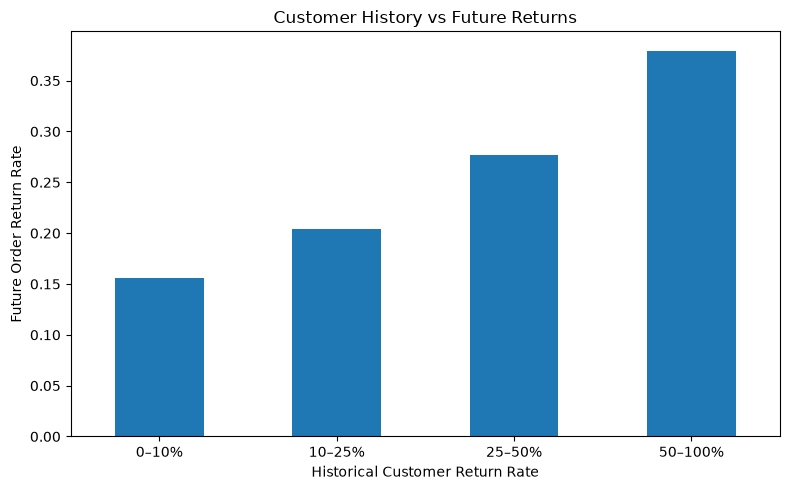

In [5]:
df['customer_return_rate_band'] = pd.cut(
    df['customer_return_rate'],
    bins=[-0.001, 0.10, 0.25, 0.50, 1.00],
    labels=['0–10%', '10–25%', '25–50%', '50–100%']
)

customer_history = (
    df.groupby('customer_return_rate_band', observed=False)
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
)
display(customer_history.style.format({'return_rate': '{:.1%}'}))

plt.figure(figsize=(8, 5))
customer_history['return_rate'].plot(kind='bar')
plt.xlabel('Historical Customer Return Rate')
plt.ylabel('Future Order Return Rate')
plt.title('Customer History vs Future Returns')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Discount vs return rate

,orders,return_rate
discount_bucket,,
High,9686,23.7%
Low,9975,18.4%
Medium,19031,21.6%
Very High,1308,25.7%


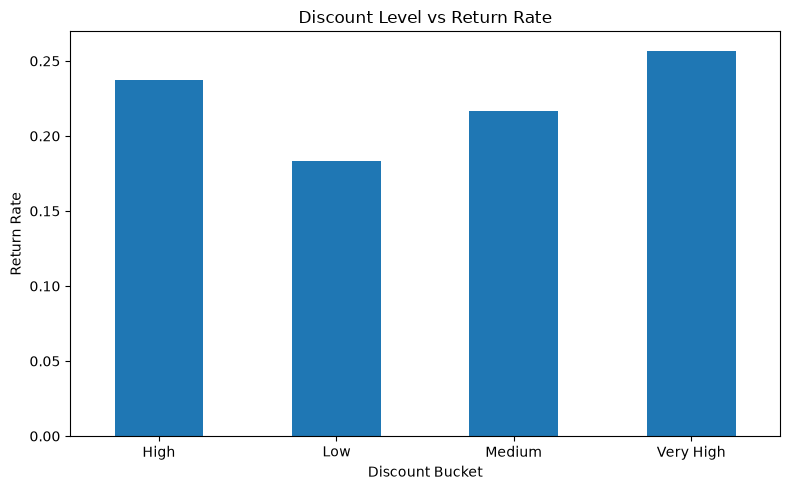

In [6]:
discount_returns = (
    df.groupby('discount_bucket', observed=False)
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
)
display(discount_returns.style.format({'return_rate': '{:.1%}'}))

plt.figure(figsize=(8, 5))
discount_returns['return_rate'].plot(kind='bar')
plt.xlabel('Discount Bucket')
plt.ylabel('Return Rate')
plt.title('Discount Level vs Return Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Payment type vs return rate

,orders,return_rate
payment_type,,
COD,7178,25.1%
Debit Card,7124,20.8%
Credit Card,8905,20.8%
UPI,14393,20.7%
Wallet,2400,19.6%


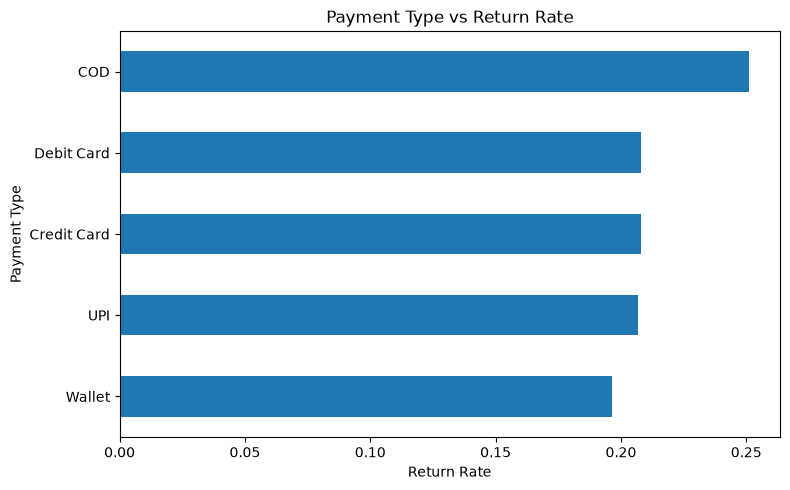

In [7]:
payment_returns = (
    df.groupby('payment_type')
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
      .sort_values('return_rate', ascending=False)
)
display(payment_returns.style.format({'return_rate': '{:.1%}'}))

plt.figure(figsize=(8, 5))
payment_returns['return_rate'].sort_values().plot(kind='barh')
plt.xlabel('Return Rate')
plt.ylabel('Payment Type')
plt.title('Payment Type vs Return Rate')
plt.tight_layout()
plt.show()

## 7. Product rating vs return rate

,orders,return_rate
rating_band,,
≤3.0,570,28.1%
3.0–3.5,4525,25.1%
3.5–4.0,14313,22.8%
4.0–4.5,15277,20.2%
4.5–5.0,5315,17.6%


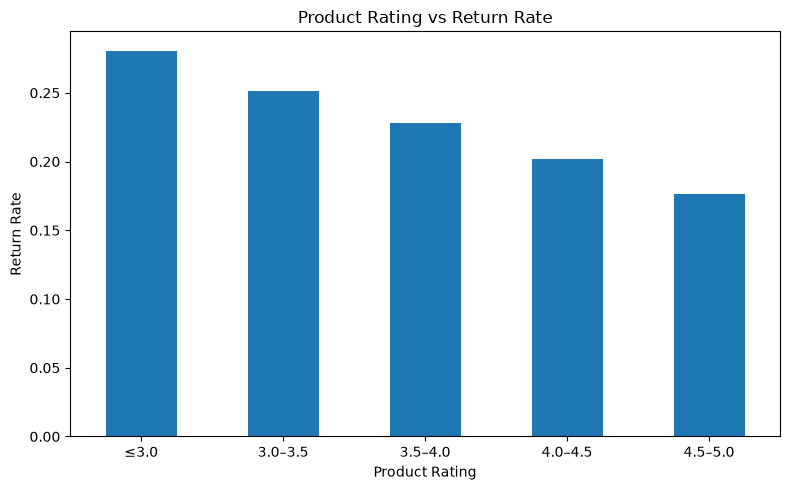

In [8]:
df['rating_band'] = pd.cut(
    df['product_rating'],
    bins=[0, 3, 3.5, 4, 4.5, 5.01],
    labels=['≤3.0', '3.0–3.5', '3.5–4.0', '4.0–4.5', '4.5–5.0']
)

rating_returns = (
    df.groupby('rating_band', observed=False)
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
)
display(rating_returns.style.format({'return_rate': '{:.1%}'}))

plt.figure(figsize=(8, 5))
rating_returns['return_rate'].plot(kind='bar')
plt.xlabel('Product Rating')
plt.ylabel('Return Rate')
plt.title('Product Rating vs Return Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Logistics: distance and expected delivery time

,orders,return_rate
distance_band,,
"(0.999, 6.8]",8121,19.8%
"(6.8, 10.9]",7890,20.5%
"(10.9, 15.7]",8006,21.6%
"(15.7, 22.8]",8046,22.0%
"(22.8, 91.0]",7937,23.5%


,orders,return_rate
expected_delivery_days,,
1,1127,21.1%
2,10103,21.0%
3,19613,21.7%
4,8251,21.4%
5,870,23.1%
6,36,22.2%


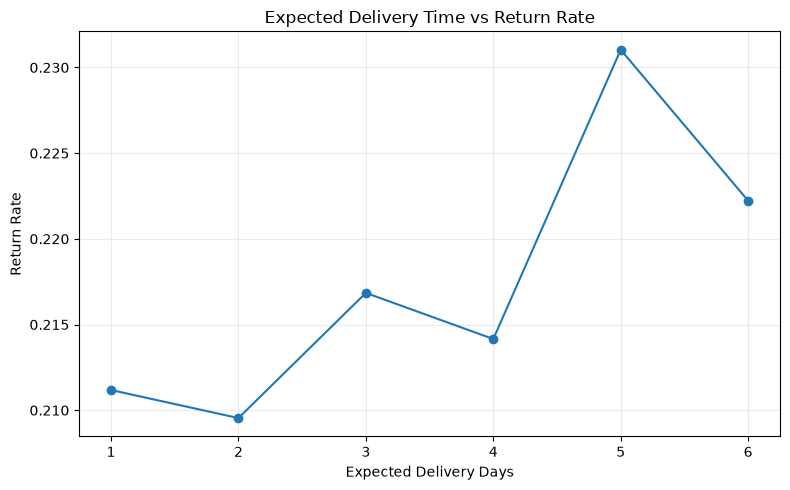

In [9]:
df['distance_band'] = pd.qcut(
    df['delivery_distance_km'],
    q=5,
    duplicates='drop'
)

distance_returns = (
    df.groupby('distance_band', observed=False)
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
)
display(distance_returns.style.format({'return_rate': '{:.1%}'}))

delivery_returns = (
    df.groupby('expected_delivery_days')
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
)
display(delivery_returns.style.format({'return_rate': '{:.1%}'}))

plt.figure(figsize=(8, 5))
delivery_returns['return_rate'].plot(kind='line', marker='o')
plt.xlabel('Expected Delivery Days')
plt.ylabel('Return Rate')
plt.title('Expected Delivery Time vs Return Rate')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Numeric feature relationships

We inspect simple correlations with the binary target. Correlation is descriptive, not causal.

In [10]:
numeric_features = [
    'product_price', 'product_rating',
    'product_historical_return_rate', 'customer_age',
    'customer_previous_orders', 'customer_previous_returns',
    'customer_return_rate', 'quantity', 'discount_pct',
    'delivery_distance_km', 'expected_delivery_days',
    'returned'
]

correlations = (
    df[numeric_features]
      .corr(numeric_only=True)['returned']
      .drop('returned')
      .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(correlations.to_frame('correlation_with_returned'))

,correlation_with_returned
product_historical_return_rate,0.189
customer_return_rate,0.158
customer_previous_returns,0.139
product_rating,-0.057
discount_pct,0.052
delivery_distance_km,0.035
quantity,0.024
product_price,0.013
expected_delivery_days,0.006
customer_previous_orders,-0.003


## 10. Monthly return trend

,orders,return_rate
order_date,,
2025-01,3407,22.6%
2025-02,3077,21.3%
2025-03,3406,21.0%
2025-04,3297,20.6%
2025-05,3406,21.4%
2025-06,3297,20.0%
2025-07,3407,22.2%
2025-08,3406,21.5%
2025-09,3297,20.5%


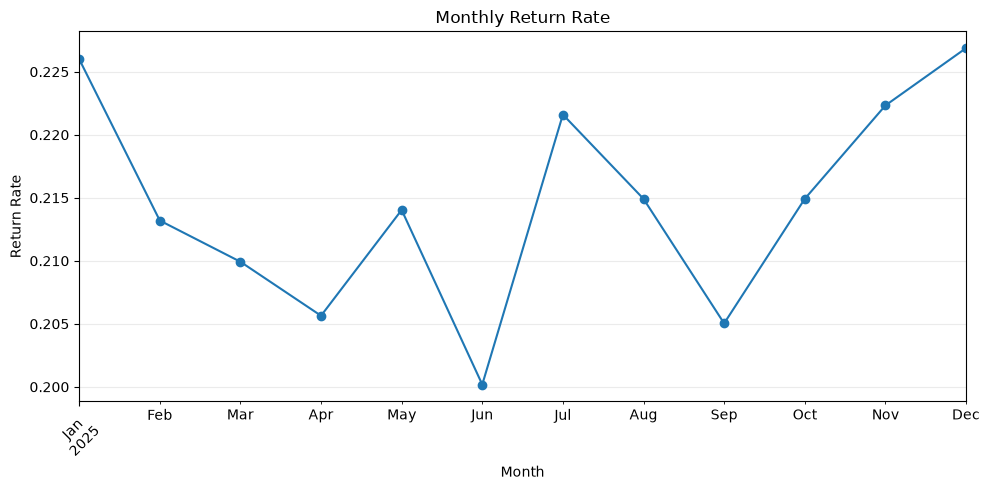

In [11]:
monthly_returns = (
    df.groupby(df['order_date'].dt.to_period('M'))
      .agg(orders=('order_id', 'count'), return_rate=('returned', 'mean'))
)
display(monthly_returns.style.format({'return_rate': '{:.1%}'}))

plt.figure(figsize=(10, 5))
monthly_returns['return_rate'].plot(marker='o')
plt.xlabel('Month')
plt.ylabel('Return Rate')
plt.title('Monthly Return Rate')
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Business hypothesis summary

The cells above should be used to turn exploratory patterns into hypotheses for modeling. Avoid treating these descriptive relationships as causal effects.

In [12]:
print('EDA checklist')
print('✓ Base return rate')
print('✓ Category differences')
print('✓ Customer historical behavior')
print('✓ Discount behavior')
print('✓ Payment behavior')
print('✓ Product rating')
print('✓ Logistics')
print('✓ Numeric correlations')
print('✓ Time trend')

print('\nNext modeling step:')
print('1. Define the final feature set using only order-time information.')
print('2. Split chronologically to respect the prediction setting.')
print('3. Establish a Logistic Regression baseline.')
print('4. Compare against a tree-based model.')

EDA checklist
✓ Base return rate
✓ Category differences
✓ Customer historical behavior
✓ Discount behavior
✓ Payment behavior
✓ Product rating
✓ Logistics
✓ Numeric correlations
✓ Time trend

Next modeling step:
1. Define the final feature set using only order-time information.
2. Split chronologically to respect the prediction setting.
3. Establish a Logistic Regression baseline.
4. Compare against a tree-based model.
